In [29]:
import torch
print(torch.cuda.is_available())

True


In [30]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
print("Detectron2 başarıyla kuruldu!")

Detectron2 başarıyla kuruldu!


In [31]:
import numpy as np
import os

# Veri seti dizin yolu
data_path = 'D:/Thermal/train/images/'

# Örnek bir dosya yükleme (DJI_0004_R.npy dosyasını yükleme)
sample_file = os.path.join(data_path, 'Flug1_100', 'DJI_0047_R.npy')
data = np.load(sample_file)

# Verinin boyutlarını kontrol edin
print(data.shape)



(2400, 3200, 5)


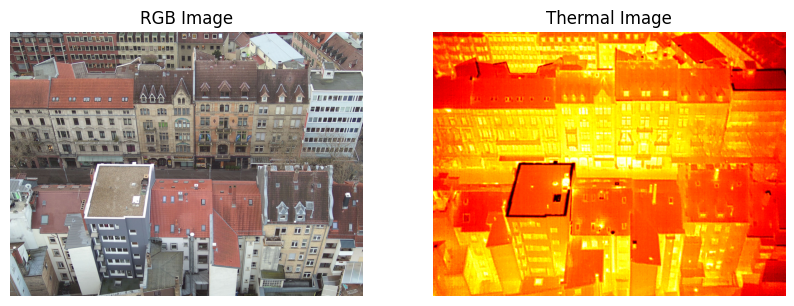

In [32]:
import matplotlib.pyplot as plt
import cv2

# RGB görüntüyü ve termal görüntüyü ayırın
rgb_image = data[:, :, :3]  # İlk üç kanal RGB
thermal_image = data[:, :, 3]  # Dördüncü kanal termal

# RGB görüntüyü göstermek için
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("RGB Image")
plt.imshow(cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB))  # BGR'yi RGB'ye çevirme
plt.axis('off')

# Termal görüntüyü göstermek için
plt.subplot(1, 2, 2)
plt.title("Thermal Image")
plt.imshow(thermal_image, cmap='hot')
plt.axis('off')

plt.show()


In [33]:
from pycocotools.coco import COCO

# Eğitim etiket dosyasının yolunu belirtin
annotation_file = os.path.join(data_path, 'ann.json')

# COCO formatında etiketleri yükleyin
coco = COCO(annotation_file)

# İlk birkaç anotasyonu göster
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids[:5])
print(anns)


loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
[{'id': 1, 'image_id': 0, 'bbox': [1315.0, 1421.0, 53.0, 102.0], 'area': 2186.5, 'iscrowd': 0, 'category_id': 0, 'segmentation': [[1319.0, 1446.0, 1337.0, 1421.0, 1337.0, 1456.0, 1368.0, 1456.0, 1323.0, 1523.0, 1315.0, 1449.0, 1319.0, 1446.0]]}, {'id': 2, 'image_id': 0, 'bbox': [224.0, 20.0, 129.0, 3.0], 'area': 233.0, 'iscrowd': 0, 'category_id': 0, 'segmentation': [[236.0, 23.0, 224.0, 23.0, 236.0, 23.0, 254.0, 23.0, 302.0, 23.0, 332.0, 23.0, 353.0, 23.0, 351.0, 20.0, 236.0, 22.0]]}, {'id': 3, 'image_id': 1, 'bbox': [1312.0, 1480.0, 71.0, 121.0], 'area': 3804.0, 'iscrowd': 0, 'category_id': 0, 'segmentation': [[1313.0, 1516.0, 1325.0, 1480.0, 1337.0, 1502.0, 1328.0, 1525.0, 1380.0, 1528.0, 1383.0, 1533.0, 1377.0, 1539.0, 1368.0, 1556.0, 1347.0, 1570.0, 1337.0, 1580.0, 1328.0, 1595.0, 1318.0, 1601.0, 1312.0, 1597.0, 1313.0, 1519.0, 1313.0, 1516.0]]}, {'id': 4, 'image_id': 1, 'bbox': [1214.0, 414.0, 489.

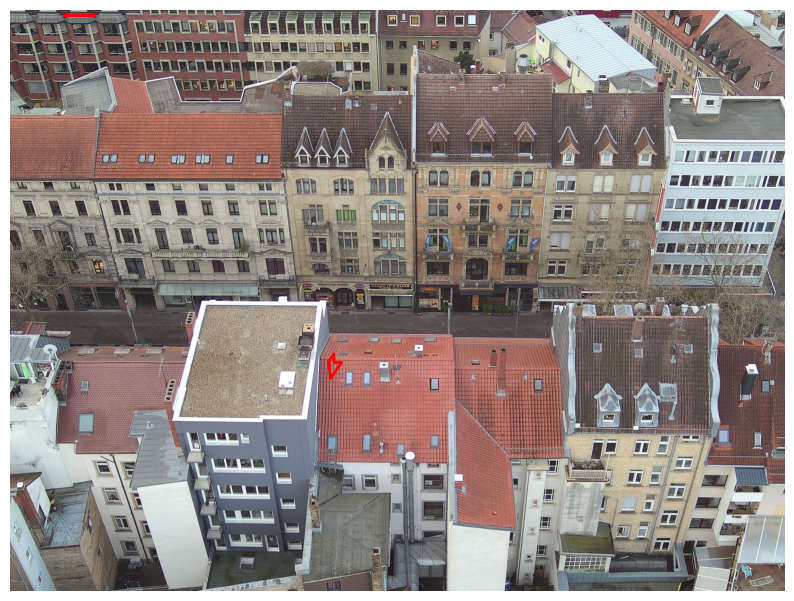

In [34]:
# Örnek bir görüntünün ID'sini alın
image_id = coco.getImgIds()[0]
image_info = coco.loadImgs(image_id)[0]

# Görüntü dosyasının yolunu alın
file_name_cleaned = image_info['file_name'].replace("images/", "").replace("images\\", "")
image_file = os.path.join(data_path, file_name_cleaned)

# Görüntüyü yükleyin
image = np.load(image_file)

# RGB görüntüyü ayırın
rgb_image = image[:, :, :3]

# Anotasyonları yükleyin
ann_ids = coco.getAnnIds(imgIds=image_id)
anns = coco.loadAnns(ann_ids)

# Görüntüyü ve anotasyonları görselleştirin
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Anotasyonları çizmek için
for ann in anns:
    poly = np.array(ann['segmentation'][0]).reshape((len(ann['segmentation'][0]) // 2, 2))
    plt.plot(poly[:, 0], poly[:, 1], 'r', linewidth=2)

plt.show()


In [35]:
import json
import os

# JSON dosyasının yolunu belirtin
json_path = "D:/Thermal/train/images/ann.json"

# JSON dosyasını yükleyin
with open(json_path) as f:
    data = json.load(f)

# JSON dosyasının anahtarlarını kontrol edin
print(data.keys())


dict_keys(['info', 'images', 'categories', 'licenses', 'annotations'])


In [36]:
import detectron2
print("Detectron2 başarıyla kuruldu!")


Detectron2 başarıyla kuruldu!


In [37]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo


In [ ]:
import os
import numpy as np
import json
import cv2  # OpenCV kütüphanesini ekledik
from detectron2.structures import BoxMode
from PIL import Image
from detectron2.data import DatasetCatalog, MetadataCatalog

def get_tbbr_dicts(img_dir):
    # JSON dosyasının img_dir içinde olduğu varsayılıyor
    json_file = os.path.join(img_dir, "ann.json")
    with open(json_file) as f:
        img_anns = json.load(f)

    dataset_dicts = []
    # JSON yapısına göre "images" listesi dönülüyor
    for idx, v in enumerate(img_anns["images"]):
        record = {}
        
        # Dosya yolu oluşturma
        filename = os.path.join(img_dir, v["file_name"])
        
        # .npy dosyalarını yükleyip görsel formatına çevirme işlemi
        if filename.endswith('.npy'):
            array = np.load(filename)
            
            # --- DEĞİŞİKLİK 1: RGB YERİNE TERMAL KANAL KULLANIMI ---
            # Veri setinizde 4. kanal (index 3) termal veridir.
            thermal_data = array[:, :, 3]
            
            # Veriyi 0-255 arasına normalize et (Görüntü oluşturmak için şart)
            norm_thermal = cv2.normalize(thermal_data, None, 0, 255, cv2.NORM_MINMAX)
            norm_thermal = norm_thermal.astype(np.uint8)
            
            # Termal veriyi "Renkli Isı Haritasına" (Jet Colormap) çevir
            # Bu sayede sıcak yerler kırmızı, soğuk yerler mavi görünür.
            thermal_colormap = cv2.applyColorMap(norm_thermal, cv2.COLORMAP_JET)
            
            # OpenCV BGR formatını RGB'ye çevirip PIL Image yapıyoruz
            image = Image.fromarray(cv2.cvtColor(thermal_colormap, cv2.COLOR_BGR2RGB))
            # -------------------------------------------------------

            # Save as a temporary image file
            temp_filename = filename[:-4] + '.jpg' 
            image.save(temp_filename)
            filename = temp_filename

        height, width = v["height"], v["width"]
        
        record["file_name"] = filename
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width
      
        objs = []
        for anno in img_anns["annotations"]:
            if anno["image_id"] == v["id"]:
                px = anno["segmentation"][0][::2]
                py = anno["segmentation"][0][1::2]
                poly = [(x, y) for x, y in zip(px, py)]

                obj = {
                    "bbox": [np.min(px), np.min(py), np.max(px), np.max(py)],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "segmentation": [poly],
                    
                    # --- DEĞİŞİKLİK 2: ID SABİTLEME ---
                    # JSON'dan ne gelirse gelsin, tek sınıf olduğu için 0 yapıyoruz.
                    "category_id": 0, 
                    # ----------------------------------
                }
                objs.append(obj)
        record["annotations"] = objs
        dataset_dicts.append(record)
    return dataset_dicts


if "tbbr_train" in DatasetCatalog.list():
    DatasetCatalog.remove("tbbr_train")
if "tbbr_test" in DatasetCatalog.list():
    DatasetCatalog.remove("tbbr_test")

# tbbr_train veri setini kaydet
DatasetCatalog.register("tbbr_train", lambda d="train": get_tbbr_dicts("D:/Thermal/train/images"))
MetadataCatalog.get("tbbr_train").set(thing_classes=["thermal_bridge"])

# tbbr_test veri setini kaydet
DatasetCatalog.register("tbbr_test", lambda d="test": get_tbbr_dicts("D:/Thermal/test/images"))
MetadataCatalog.get("tbbr_test").set(thing_classes=["thermal_bridge"])

tbbr_metadata = MetadataCatalog.get("tbbr_train")
print("Veri setleri TERMAL modunda ve düzeltilmiş ID ile yeniden tanımlandı!")

Veri setleri TERMAL modunda ve düzeltilmiş ID ile yeniden tanımlandı!


In [39]:
from detectron2.data import DatasetCatalog, MetadataCatalog
import cv2
import os

# 1. Önce hatalı kaydı temizleyelim (Hata almamak için try-except içine aldık)
try:
    DatasetCatalog.remove("tbbr_train")
    DatasetCatalog.remove("tbbr_test")
except:
    pass

# 2. Boyutları düzelten yardımcı fonksiyon
def get_tbbr_dicts_fixed(img_dir):
    # Senin orijinal fonksiyonunu çağırıp verileri alıyoruz
    dataset_dicts = get_tbbr_dicts(img_dir)
    
    # Her bir resim için gerçek boyutları kontrol edip güncelliyoruz
    for record in dataset_dicts:
        filename = record["file_name"]
        # Resmi opencv ile hızlıca okuyoruz
        img = cv2.imread(filename)
        if img is not None:
            h, w = img.shape[:2]
            # JSON'daki yanlış bilgiyi gerçek bilgiyle değiştiriyoruz
            record["height"] = h
            record["width"] = w
            
    return dataset_dicts

# 3. Veri setini "Düzeltilmiş" fonksiyon ile tekrar kaydediyoruz
DatasetCatalog.register("tbbr_train", lambda d="train": get_tbbr_dicts_fixed("D:/Thermal/train/images"))
MetadataCatalog.get("tbbr_train").set(thing_classes=["thermal_bridge"])

DatasetCatalog.register("tbbr_test", lambda d="test": get_tbbr_dicts_fixed("D:/Thermal/test/images"))
MetadataCatalog.get("tbbr_test").set(thing_classes=["thermal_bridge"])

print("Veri seti boyut hataları düzeltilerek yeniden yüklendi!")

Veri seti boyut hataları düzeltilerek yeniden yüklendi!


In [ ]:
from detectron2.solver import build_lr_scheduler, build_optimizer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer
import os

cfg = get_cfg()
# Mask R-CNN modelini seçiyoruz
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# Veri setlerini tanımla
cfg.DATASETS.TRAIN = ("tbbr_train",)
cfg.DATASETS.TEST = ("tbbr_test",)
cfg.DATALOADER.NUM_WORKERS = 2

# Başlangıç ağırlıklarını yükle
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# 1. Batch Size Ayarı 
cfg.SOLVER.IMS_PER_BATCH = 2  

# 2. Backbone Kilidini Aç (CRITICAL FOR THERMAL)
cfg.MODEL.BACKBONE.FREEZE_AT = 0  

cfg.SOLVER.OPTIMIZER = "SGD"
cfg.SOLVER.BASE_LR = 0.002  # Batch size küçük olduğu için LR'yi düşük tutuyoruz
cfg.SOLVER.MOMENTUM = 0.9

# 4. Daha Uzun Eğitim
cfg.SOLVER.MAX_ITER = 8000   # Toplam eğitim iterasyonu sayısı
cfg.SOLVER.STEPS = (6000, 7500) # LR'nin düşürüleceği adımlar
cfg.SOLVER.GAMMA = 0.1

# ROI Heads Ayarları
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128 
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1 # Sadece 'thermal_bridge' sınıfı (ID:0)

# Çıktı klasörü
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Eğitimi Başlat
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False) # Sıfırdan başlatıyoruz
trainer.train()

[01/04 22:13:07 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[01/04 22:18:49 d2.engine.train_loop]: Starting training from iteration 0
[01/04 22:19:18 d2.utils.events]:  eta: 1:06:43  iter: 19  total_loss: 2.743  loss_cls: 0.5486  loss_box_reg: 0.06129  loss_mask: 0.6928  loss_rpn_cls: 1.177  loss_rpn_loc: 0.4096    time: 0.5129  last_time: 0.5220  data_time: 0.9325  last_data_time: 0.0030   lr: 3.9962e-05  max_mem: 4543M
[01/04 22:19:28 d2.utils.events]:  eta: 1:03:53  iter: 39  total_loss: 2.264  loss_cls: 0.354  loss_box_reg: 0.07211  loss_mask: 0.6861  loss_rpn_cls: 0.5841  loss_rpn_loc: 0.4648    time: 0.4892  last_time: 0.4504  data_time: 0.0031  last_data_time: 0.0031   lr: 7.9922e-05  max_mem: 4543M
[01/04 22:19:37 d2.utils.events]:  eta: 1:03:44  iter: 59  total_loss: 1.854  loss_cls: 0.2842  loss_box_reg: 0.07148  loss_mask: 0.6752  loss_rpn_cls: 0.432  loss_rpn_loc: 0.3521    time: 0.4850  last_time: 0.5327  data_time: 0.0032  last_data_time: 0.0038   lr: 0.00011988  max_mem: 4543M
[01/04 22:19:47 d2.utils.events]:  eta: 1:05:10  iter

[01/05 00:14:29 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output\model_final.pth ...


c:\Users\umuts\venv\lib\site-packages\fvcore\common\checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.device("cpu"))


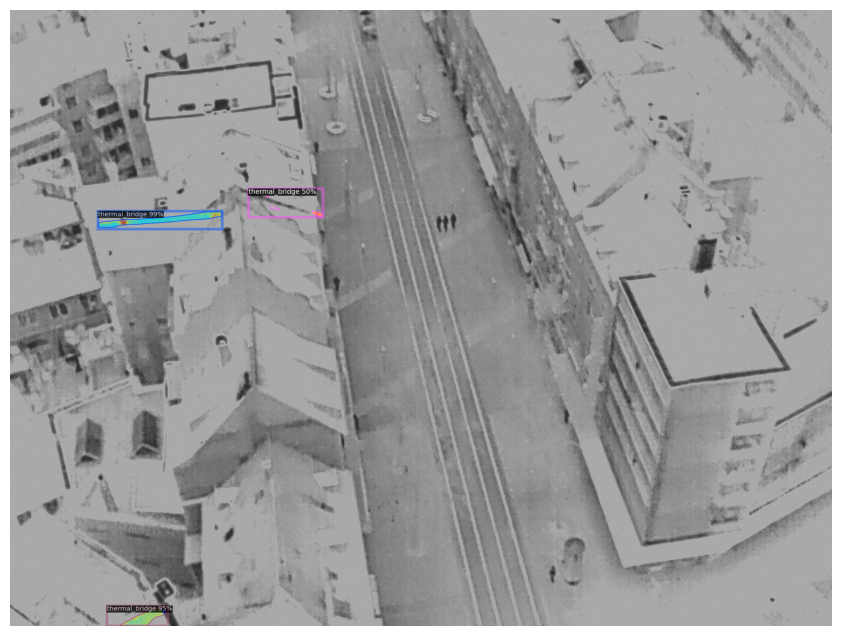

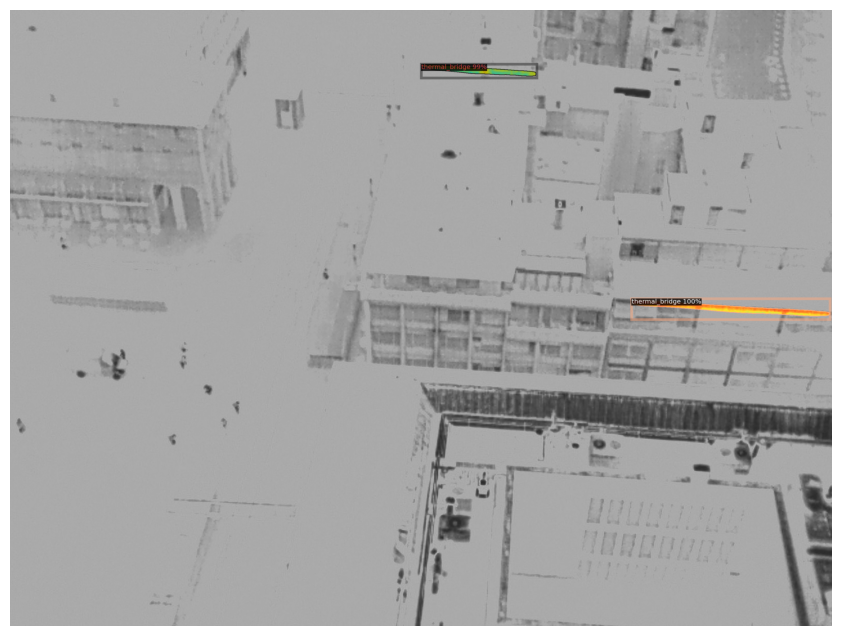

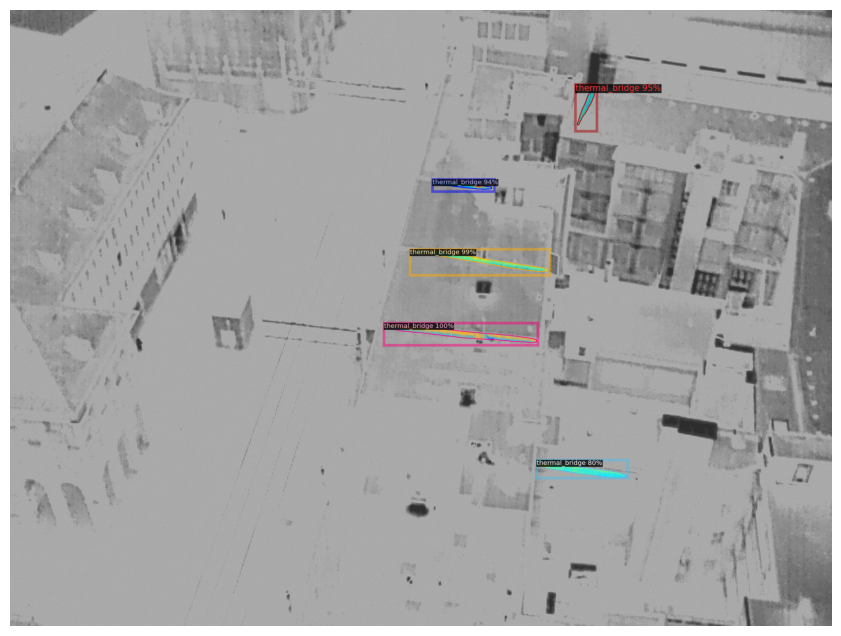

In [63]:
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
import random
import cv2
import os
import matplotlib.pyplot as plt  


cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # %50'nin üzerindeki tahminleri göster
predictor = DefaultPredictor(cfg)

dataset_dicts = get_tbbr_dicts("D:/Thermal/test/images")

for d in random.sample(dataset_dicts, 3):
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)
    
    
    v = Visualizer(im[:, :, ::-1],
                   metadata=tbbr_metadata, 
                   scale=0.8, 
                   instance_mode=ColorMode.IMAGE_BW
    )
    
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    
    
    plt.figure(figsize=(12, 8))
    plt.imshow(out.get_image()) 
    plt.axis("off") # Çerçevenin etrafındaki sayıları gizle
    plt.show()

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
import os
from detectron2.data import DatasetCatalog, MetadataCatalog

# Test setini kayıt et (Eğer daha önce yapılmadıysa)
if "tbbr_test" not in DatasetCatalog.list():
    DatasetCatalog.register("tbbr_test", lambda: get_tbbr_dicts("D:/Thermal/test/images"))
    MetadataCatalog.get("tbbr_test").set(thing_classes=["thermal_bridge"]) # Sınıf isminizi buraya yazın

# Config dosyasında test setini güncelle
cfg.DATASETS.TEST = ("tbbr_test",)

# Değerlendirme sonuçlarının kaydedileceği klasör
output_folder = "./output_evaluation"
os.makedirs(output_folder, exist_ok=True)

dataset_name = cfg.DATASETS.TEST[0] 

# Evaluator'ı başlat
evaluator = COCOEvaluator(dataset_name, output_dir=output_folder)

# Test veri yükleyicisini (Data Loader) oluştur
val_loader = build_detection_test_loader(cfg, dataset_name)

# Değerlendirmeyi çalıştır ve sonuçları yazdır
print("Değerlendirme başlıyor...")
results = inference_on_dataset(predictor.model, val_loader, evaluator)
print("Değerlendirme Sonuçları:")
print(results)

[01/05 00:17:24 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[01/05 00:17:24 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[01/05 00:17:24 d2.data.common]: Serializing 203 elements to byte tensors and concatenating them all ...
[01/05 00:17:24 d2.data.common]: Serialized dataset takes 0.39 MiB
Değerlendirme başlıyor...
[01/05 00:17:24 d2.evaluation.evaluator]: Start inference on 203 batches
[01/05 00:17:41 d2.evaluation.evaluator]: Inference done 11/203. Dataloading: 0.0011 s/iter. Inference: 0.1655 s/iter. Eval: 0.1858 s/iter. Total: 0.3524 s/iter. ETA=0:01:07
[01/05 00:17:46 d2.evaluation.evaluator]: Inference done 24/203. Dataloading: 0.0014 s/iter. Inference: 0.1621 s/iter. Eval: 0.2120 s/iter. Total: 0.3756 s/iter. ETA=0:01:07
[01/05 00:17:51 d2.evaluation.evaluator]: Inference done 34/203. Dataloading: 0.0015